In [8]:
import sqlite3
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

print(" librerias instaladas con exito")

 librerias instaladas con exito


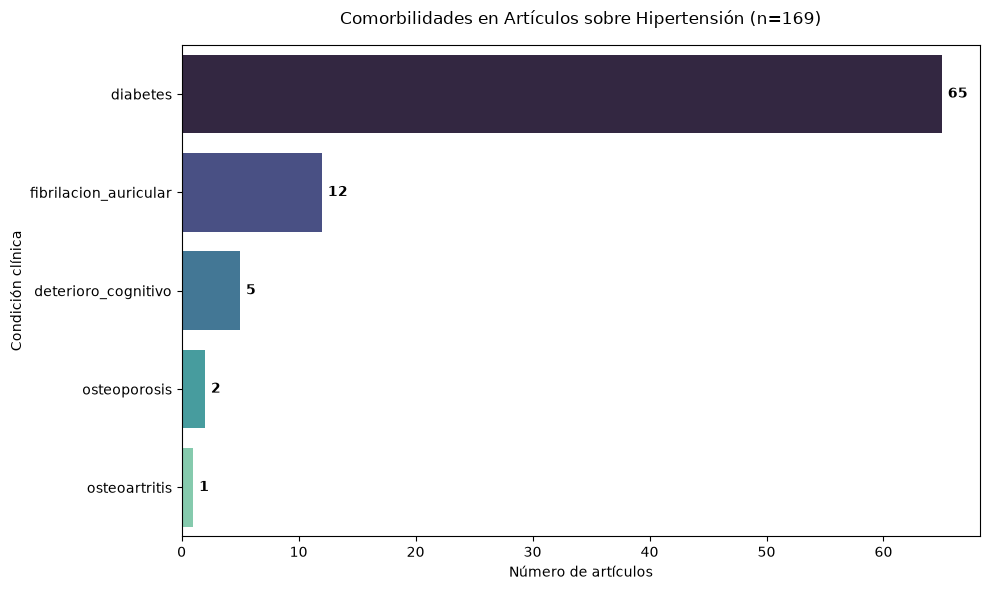

In [3]:
conn = sqlite3.connect("../cardioresearch.db")
df = pd.read_sql_query("SELECT pmid, title, abstract FROM articles", conn)
conn.close()

df['title'] = df['title'].fillna('')
df['abstract'] = df['abstract'].fillna('')
df['texto'] = (df['title'] + " " + df['abstract']).str.lower()

patrones = {
    "hipertension": r"\b(hypertension|blood pressure)\b",
    "deterioro_cognitivo": r"\b(cognitive impairment|dementia|mci)\b",
    "fibrilacion_auricular": r"\b(atrial fibrillation|afib)\b",
    "osteoartritis": r"\b(osteoarthritis)\b",
    "osteoporosis": r"\b(osteoporosis)\b",
    "diabetes": r"\b(diabetes|t2dm|mellitus)\b",
}
for cond, pat in patrones.items():
    df[cond] = df['texto'].apply(lambda x: 1 if re.search(pat, x) else 0)

df_hta = df[df['hipertension'] == 1]
comorbilidades = ["diabetes", "deterioro_cognitivo", "fibrilacion_auricular", "osteoartritis", "osteoporosis"]
frecuencias = df_hta[comorbilidades].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=frecuencias.values, y=frecuencias.index, hue=frecuencias.index, palette="mako", legend=False)
plt.title(f"Comorbilidades en Artículos sobre Hipertensión (n={len(df_hta)})", pad=15)
plt.xlabel("Número de artículos")
plt.ylabel("Condición clínica")
for i, v in enumerate(frecuencias.values):
    ax.text(v + 0.5, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()